# KMeans Clustering

Create synthetic clusters, scale the features, fit KMeans, visualize the clusters, and assign one new datapoint.

In [1]:
# 1. Import statements
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


In [2]:
# 2. Getting the dataset
X, true_labels = make_blobs(
    n_samples=500,
    centers=5,
    cluster_std=1.2,
    random_state=10,
)

print('Feature shape:', X.shape)


Feature shape: (500, 2)


In [3]:
# 3. Scaling the dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Scaled feature mean:', X_scaled.mean(axis=0).round(3))
print('Scaled feature std:', X_scaled.std(axis=0).round(3))


Scaled feature mean: [0. 0.]
Scaled feature std: [1. 1.]


In [4]:
# 4. Applying the algorithm
kmeans = KMeans(n_clusters=5, random_state=10, n_init='auto')
cluster_labels = kmeans.fit_predict(X_scaled)
score = silhouette_score(X_scaled, cluster_labels)

print(f'Silhouette score: {score:.3f}')


Silhouette score: 0.749


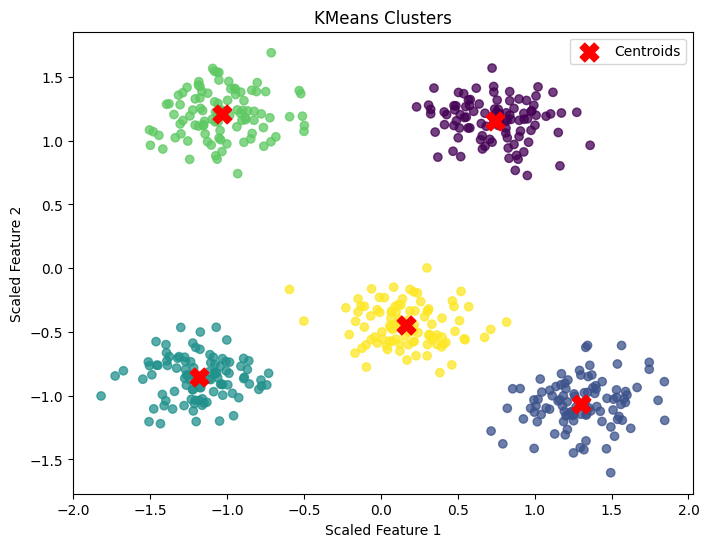

In [5]:
# 5. Graphing the clusters
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=cluster_labels, cmap='viridis', alpha=0.75)
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    c='red',
    marker='X',
    s=180,
    label='Centroids',
)
plt.title('KMeans Clusters')
plt.xlabel('Scaled Feature 1')
plt.ylabel('Scaled Feature 2')
plt.legend()
plt.show()


In [6]:
# 6. Testing against one datapoint
new_point = [[-3.0, 2.0]]
new_point_scaled = scaler.transform(new_point)
predicted_cluster = kmeans.predict(new_point_scaled)[0]

print('New datapoint:', new_point[0])
print('Predicted cluster:', predicted_cluster)


New datapoint: [-3.0, 2.0]
Predicted cluster: 3
